<a href="https://colab.research.google.com/github/Qalb-e-Momin777/Practices/blob/main/PyTorch_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

what_were_covering = {1: "data (prepare and load)",
    2: "build model",
    3: "fitting the model to data (training)",
    4: "making predictions and evaluating a model (inference)",
    5: "saving and loading a model",
    6: "putting it all together"
}

1. Data (preparing and loading)
I want to stress that "data" in machine learning can be almost anything you can imagine. A table of numbers (like a big Excel spreadsheet), images of any kind, videos (YouTube has lots of data!), audio files like songs or podcasts, protein structures, text and more.

Machine learning is a game of two parts:

Turn your data, whatever it is, into numbers (a representation).
Pick or build a model to learn the representation as best as possible.

In [126]:
import torch
from torch import nn
import matplotlib.pyplot as plt
# Linear Regression (y = mx + d)
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.02
X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight*X + bias
X[:10] , y[:10] , len(X) , len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

In [127]:
train_split = int(0.8*len(X))
X_train , y_train = X[:train_split] , y[:train_split]
X_test , y_test = X[train_split:] , y[train_split:]
len(X_train) , len(y_train) , len(X_test) , len(y_test)

(40, 40, 10, 10)

In [128]:
#visualize the data
def plot_predictions(train_data = X_train,
                    train_label = y_train,
                    test_data = X_test,
                    test_label = y_test,
                    predictions = None):
  plt.figure(figsize = (10,7))
  plt.scatter(train_data , train_label , c="b" , s = 4 , label="Training data")
  plt.scatter(test_data , test_label , c="g" , s=4, label="testing data")
  if predictions is not None:
    plt.scatter(test_data , predictions , c = "r" , s=4)
  plt.legend(prop={"size":14})

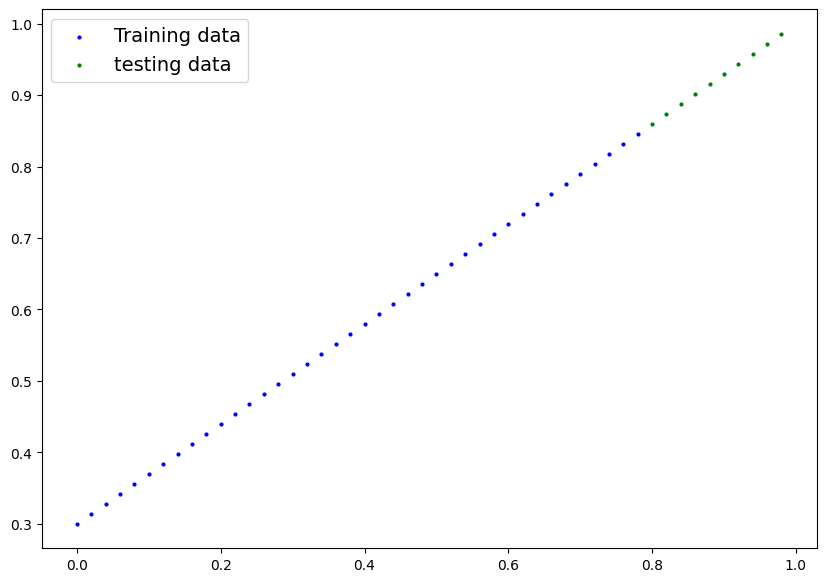

In [86]:
plot_predictions()

**Build A Model**
nn.Module is a base class for all neural networks if you want to create any model like CNN,Linear Regression etc

In [87]:
import torch
from torch import nn
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weight = nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
  def forward(self , x):
    return self.weight*x + self.bias





List()
What it does:

Returns a list of all learnable parameters (weights & biases) in the model.

state_dict()
What it does:

Returns a dictionary of all model parameters + buffers

In [129]:
torch.manual_seed(42)
model = LinearRegressionModel()
list(model.parameters())
model.state_dict()


OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [89]:
weight , bias

(0.7, 0.3)

In [130]:
# make predictions with model
# Inference_mode turn off all the training_related trackinf to make predictions (inference) faster and memory efficient
with torch.inference_mode():
  y_pred = model(X_test)
y_pred

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

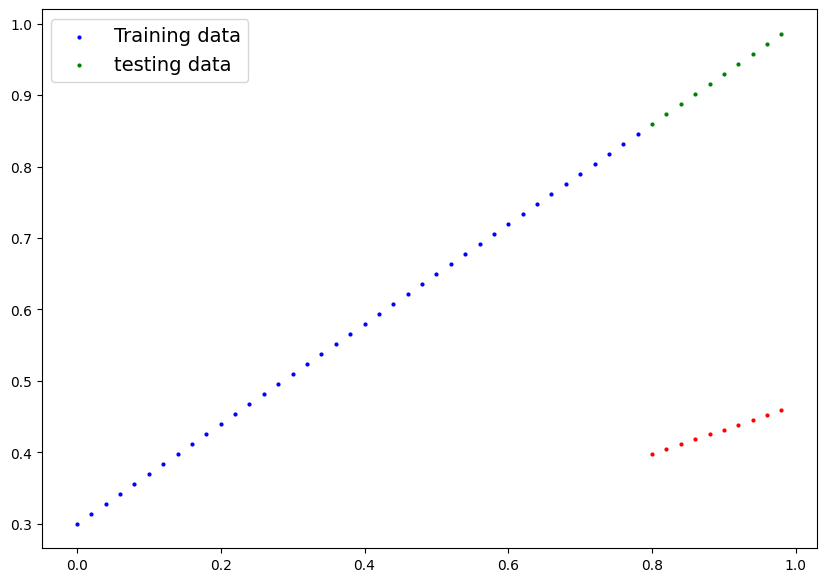

In [91]:
plot_predictions(predictions=y_pred)

In [92]:
model.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

**Loss Function**
1. Loss Functions (torch.nn)

👉 A loss function tells how wrong your model is
**Optimizer**
2. Optimizers (torch.optim)

👉 Optimizer updates model weights to reduce loss

In [131]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model.parameters() , lr=0.01)

 Building a Training Loop (and a Testing Loop)


In [158]:
torch.manual_seed(42)
# an epoch is a one loop through the data
epoch = 100
epoch_count = []
loss_values = []
test_loss_values = []
# Loop throgh the data
for epoch in range(epoch):
  # set the model to training mode
  model.train()
  # forward pass
  y_pred = model(X_train).unsqueeze(dim=1)
  # calculte the loss
  loss = loss_fn(y_pred , y_train.unsqueeze(dim=1))
  print(f"Loss : {loss}")
  # Optimizer zero grad
  optimizer.zero_grad()
  # perform backpropagation
  loss.backward()
  # optimizer step
  optimizer.step()
  # Testing
  model.eval()
  with torch.inference_mode():
    test_pred = model(X_test).unsqueeze(dim=1)
    test_loss = loss_fn(test_pred , y_test.unsqueeze(dim=1))
  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss.detach().cpu().item())
    test_loss_values.append(test_loss.detach().cpu().item())
    print(f"Epoch : {epoch} | loss : {loss} | Test Loss : {test_loss}")
    print(model.state_dict())

Loss : 0.005492396652698517
Epoch : 0 | loss : 0.005492396652698517 | Test Loss : 0.009332304820418358
OrderedDict({'weight': tensor([0.6934]), 'bias': tensor([0.2965])})
Loss : 0.006028587464243174
Loss : 0.005492396652698517
Loss : 0.006028587464243174
Loss : 0.005492396652698517
Loss : 0.006028587464243174
Loss : 0.005492396652698517
Loss : 0.006028587464243174
Loss : 0.005492396652698517
Loss : 0.006028587464243174
Loss : 0.005492396652698517
Epoch : 10 | loss : 0.005492396652698517 | Test Loss : 0.009332304820418358
OrderedDict({'weight': tensor([0.6934]), 'bias': tensor([0.2965])})
Loss : 0.006028587464243174
Loss : 0.005492396652698517
Loss : 0.006028587464243174
Loss : 0.005492396652698517
Loss : 0.006028587464243174
Loss : 0.005492396652698517
Loss : 0.006028587464243174
Loss : 0.005492396652698517
Loss : 0.006028587464243174
Loss : 0.005492396652698517
Epoch : 20 | loss : 0.005492396652698517 | Test Loss : 0.009332304820418358
OrderedDict({'weight': tensor([0.6934]), 'bias': 

In [123]:
weight , bias

(0.7, 0.3)

In [159]:
with torch.inference_mode():
  y_pred_new = model(X_test)

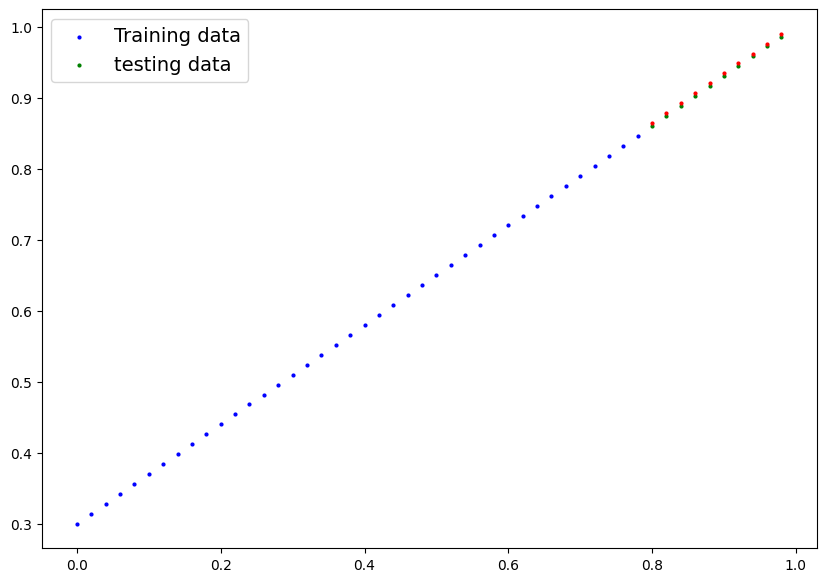

In [160]:
plot_predictions(predictions=y_pred_new)

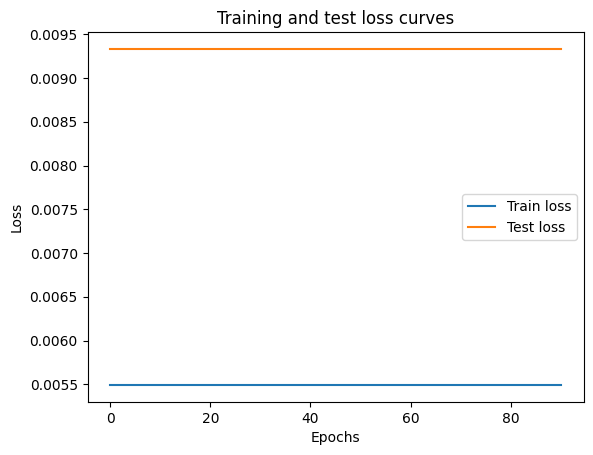

In [162]:
# Plot the loss curves
plt.plot(epoch_count, loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

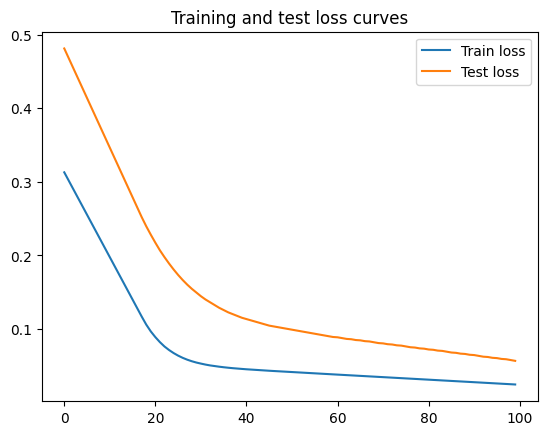

In [164]:
torch.manual_seed(42)
model = LinearRegressionModel() # Create a NEW model
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
epoch = 100
epoch_count = []
loss_values = []
test_loss_values = []

# 2. Training Loop
for epoch in range(epoch):
    model.train()
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 3. Test and Record
    model.eval()
    with torch.inference_mode():
        test_pred = model(X_test)
        test_loss = loss_fn(test_pred, y_test)

        # Record data every epoch to see a smooth curve
        epoch_count.append(epoch)
        loss_values.append(loss.item())
        test_loss_values.append(test_loss.item())

# 4. Plot
plt.plot(epoch_count, loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.legend()
plt.show()